In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# Introduction

Let me be my first race kernel.

<font color = 'blue'>
Content: 

1. [Load and Check Data](#1)
1. [Variable Description](#2)
    * [Univariate Variable Analysis](#3)
        * [Categorical Variable](#4)
        * [Numerical Variable](#5)
1. [Basic Data Analysis](#6)
1. [Outlier Detection](#7)
1. [Missing Value](#8)
1. [Visualization](#11)
    * [Correlation Between Sibsp -- Parch -- Age -- Fare -- Survived](#12)
    * [SibSp -- Survived](#13)
    * [Parch -- Survived](#14)
    * [Pclass -- Survived](#15)
    * [Age -- Survived](#16)
    * [Pclass -- Survived -- Age](#17)
    * [Embarked -- Sex -- Pclass -- Survived](#18)
    * [Embarked -- Sex -- Fare -- Survived](#19)
    * [Fill Missing: Age Feature](#20)
1. [Feature Engineering](#21)
1. [Modeling](#29)
    * [Train - Test Split](#30)
    * [Simple Logistic Regression](#31)
    * [Hyperparameter Tuning -- Grid Search -- Cross Validation](#32) 
    * [Ensemble Modeling](#33)
    * [Prediction and Submission](#34)

<a id = "1"></a> <br>
# Load and Check

In [2]:
train_df = pd.read_csv("/kaggle/input/titanic/train.csv")
test_df = pd.read_csv("/kaggle/input/titanic/test.csv")
test_PassengerId = test_df["PassengerId"]

In [3]:
test_df.shape

(418, 11)

In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


<a id = "2"></a> <br>
# Variable Description

1. PassengerId: unique id number to each passenger
2. Survived: passenger 1(survive) or 0(died)
3. Pclass: passenger class
4. Name: name
5. Sex: gender of passengers
6. Age: age of passengers
7. SibSp: number of siblings/spouses
8. Parch: number of parents/children
9. Ticket: ticket number
10. Fare: amount of money ticket
11. Cabin: cabin category
12. Embarked: port where passenger embarked (C = Cherbourg, Q = Queenstown, S = Southampton)

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* float64(2): Fare-Age
* int64(5): PassengerId,Survived,Pclass,SibSp,Parch
* object(5): Name,Sex,Ticket,Cabin,Embarked

<a id ="3"></a><br>
# Univariate Variable Analysis

* Categorical Variable: Survived,Sex,Pclass,Embarked,Name,Cabin,Ticket,SibSp,Parch
* Numerical Variable: Fare,Age,PassengerId

<a id ="4"></a><br>
## Categorical Variable

In [10]:
def bar_plot(variable):
    var = train_df[variable]
    varValue = var.value_counts()
    
    #visualize
    plt.figure(figsize = (9,5))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

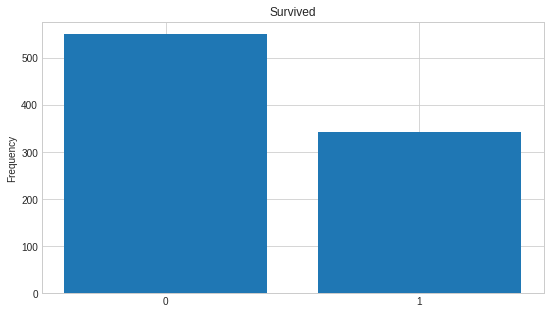

Survived: 
 0    549
1    342
Name: Survived, dtype: int64


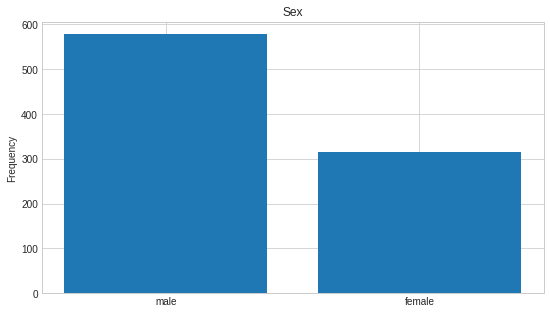

Sex: 
 male      577
female    314
Name: Sex, dtype: int64


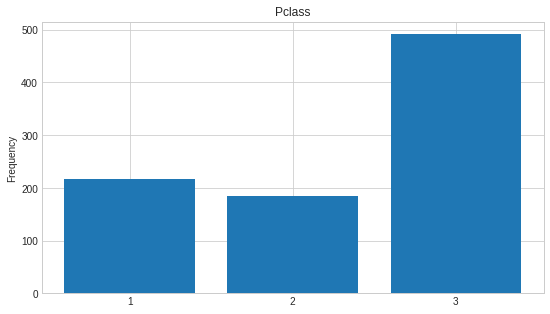

Pclass: 
 3    491
1    216
2    184
Name: Pclass, dtype: int64


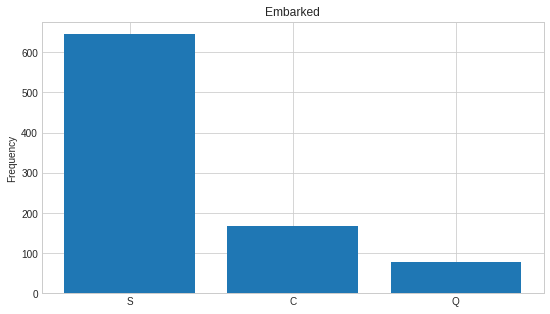

Embarked: 
 S    644
C    168
Q     77
Name: Embarked, dtype: int64


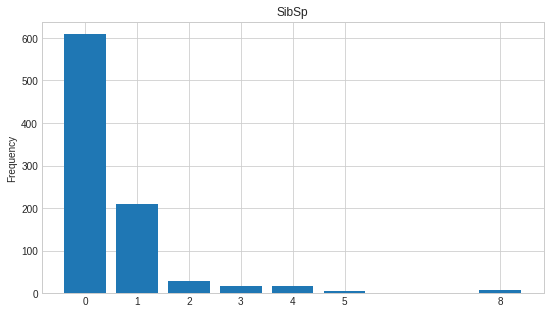

SibSp: 
 0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: SibSp, dtype: int64


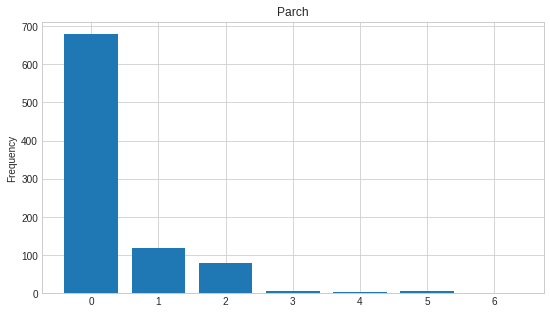

Parch: 
 0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: Parch, dtype: int64


In [11]:
category_1 = ["Survived","Sex","Pclass","Embarked","SibSp","Parch"]
for a in category_1:
    bar_plot(a)

In [12]:
category_2 = ["Cabin","Name","Ticket"]
for a in category_2:
    print("{} \n".format(train_df[a].value_counts()))

B96 B98        4
C23 C25 C27    4
G6             4
C22 C26        3
F2             3
              ..
C104           1
C7             1
C85            1
B101           1
B80            1
Name: Cabin, Length: 147, dtype: int64 

Ridsdale, Miss. Lucy              1
Gustafsson, Mr. Johan Birger      1
Nysten, Miss. Anna Sofia          1
Silvey, Mr. William Baird         1
Connors, Mr. Patrick              1
                                 ..
Richards, Master. William Rowe    1
Panula, Master. Juha Niilo        1
McCoy, Miss. Agnes                1
Davies, Mr. Charles Henry         1
LeRoy, Miss. Bertha               1
Name: Name, Length: 891, dtype: int64 

1601        7
CA. 2343    7
347082      7
CA 2144     6
347088      6
           ..
PC 17599    1
349236      1
345767      1
349214      1
PC 17590    1
Name: Ticket, Length: 681, dtype: int64 



<a id="5"></a><br>
## Numerical Variable

In [13]:
def plot_hist(variable):
    plt.figure(figsize = (9,5))
    plt.hist(train_df[variable],bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distribution with hist".format(variable))
    plt.show()

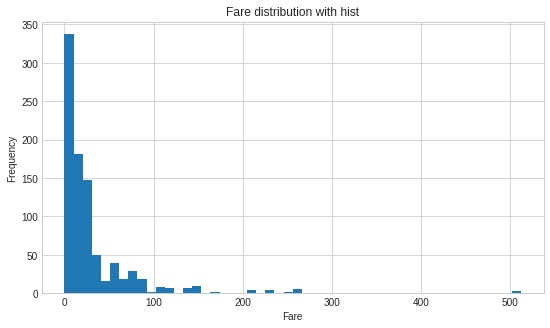

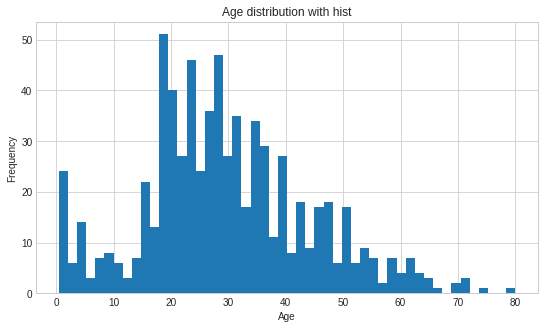

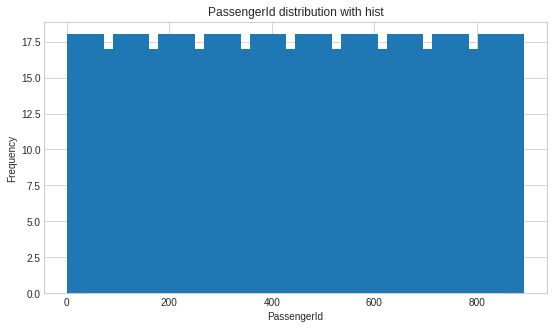

In [14]:
numeric_var = ["Fare","Age","PassengerId"]
for c in numeric_var:
    plot_hist(c)

<a id = "6"></a><br>
# Basic Data Analysis
* Pclass - Survived
* Sex - Survived
* SibSp - Survived
* Parch - Survived

In [15]:
train_df[["Pclass","Survived"]]

,Pclass,Survived
0,3,0
1,1,1
2,3,1
3,1,1
4,3,0
...,...,...
886,2,0
887,1,1
888,3,0
889,1,1


In [16]:
#Pclass vs Survived
train_df[["Pclass","Survived"]].groupby(["Pclass"], as_index = False).mean().sort_values(by = "Survived",ascending = True)

,Pclass,Survived
2,3,0.242363
1,2,0.472826
0,1,0.629630


In [17]:
# Sex vs Survived
train_df[["Sex","Survived"]].groupby(["Sex"], as_index = False).mean().sort_values(by = "Survived",ascending = False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [18]:
# SibSp vs Survived
train_df[["SibSp","Survived"]].groupby(["SibSp"], as_index = False).mean().sort_values(by = "Survived",ascending = False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [19]:
#Parch vs Survived
train_df[["Parch","Survived"]].groupby(["Parch"], as_index = False).mean().sort_values(by = "Survived",ascending = False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


<a id = "7"></a><br>
## Outlier Detection

In [20]:
def detect_outliers(df,features):
    outlier_indices = []
    
    for a in features:
        #1st quartile
        Q1 = np.percentile(df[a],25)
        #3rd quartile
        Q3 = np.percentile(df[a],75)
        #IQR
        IQR = Q3 - Q1
        #outlier step
        outlier_step = IQR * 1.5
        #detect outlier and their indeces
        outlier_list_col = df[(df[a] < Q1 - outlier_step) | (df[a] > Q3 + outlier_step)].index
        #store indeces
        outlier_indices.extend(outlier_list_col)
        
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2)
    return multiple_outliers

In [21]:
train_df.loc[detect_outliers(train_df,["Age","SibSp","Parch","Fare"])]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.00,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.00,C23 C25 C27,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.00,C23 C25 C27,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [22]:
# drop outliers
train_df = train_df.drop(detect_outliers(train_df,["Age","SibSp","Parch","Fare"]),axis = 0).reset_index(drop = True)

<a id = "8"></a><br>
## Missing Value
* Find Missing Value
* Fill Missing Value

In [23]:
train_df_len = len(train_df)
train_df = pd.concat([train_df,test_df],axis = 0).reset_index(drop = True)

In [24]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
train_df.isnull().any()

PassengerId    False
Survived        True
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare            True
Cabin           True
Embarked        True
dtype: bool

In [26]:
train_df.columns[train_df.isnull().any()]

Index(['Survived', 'Age', 'Fare', 'Cabin', 'Embarked'], dtype='object')

In [27]:
train_df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             256
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1007
Embarked          2
dtype: int64

In [28]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)

    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)

    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])

    print(missing_df, end="\n")

    if na_name:
        return na_columns

In [29]:
missing_values_table(train_df)

          n_miss  ratio
Cabin       1007  77.52
Survived     418  32.18
Age          256  19.71
Embarked       2   0.15
Fare           1   0.08


In [30]:
train_df.drop("Cabin", inplace=True, axis=1)

remove_vars = ["Ticket"]
train_df.drop(remove_vars, inplace=True, axis=1)
train_df.head()


train_df["Embarked"].value_counts()
train_df["Embarked"].fillna(train_df["Embarked"].mode()[0],inplace=True)
train_df['Age'] = train_df['Age'].fillna(train_df.groupby('Sex')['Age'].transform('median'))

In [31]:
train_df["Survived"].fillna(train_df.groupby("Sex")['Survived'].transform('median'),inplace=True)

In [32]:
missing_values_table(train_df)

      n_miss  ratio
Fare       1   0.08


In [33]:
train_df.Fare.fillna(train_df.Fare.mean(),inplace=True)

<a id = "12"></a><br>
## Visualization
## Correlation Between SibSp - Parch - Age - Fare - Survived

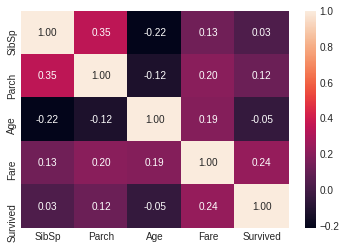

In [34]:
list1 = ["SibSp","Parch","Age","Fare","Survived"]
sns.heatmap(train_df[list1].corr(),annot = True, fmt = ".2f")
plt.show()

<a id = "13"></a><br>
## SibSp - Survived

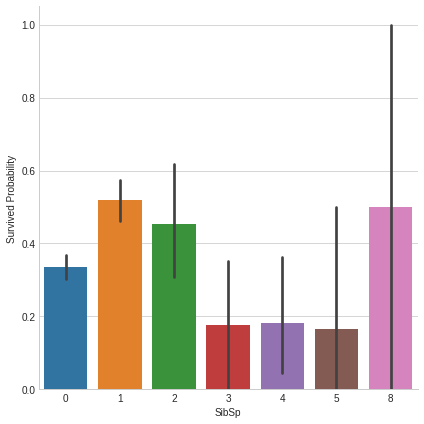

In [35]:
f = sns.factorplot(x = "SibSp", y = "Survived", data = train_df, kind="bar", size = 6)
f.set_ylabels("Survived Probability")
plt.show()

<a id = "14"></a><br>
## Parch - Survived

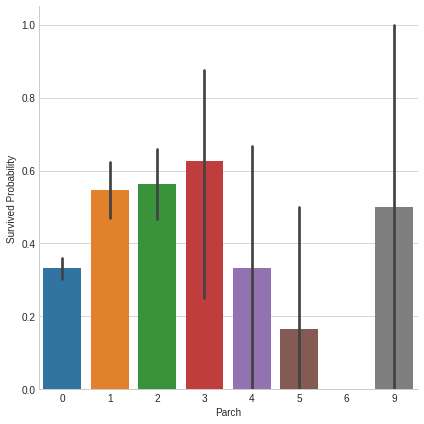

In [36]:
f = sns.factorplot(x = "Parch", y = "Survived",kind = "bar",data = train_df,size = 6)
f.set_ylabels("Survived Probability")
plt.show()

<a id = "15"></a><br>
## Pclass - Survived

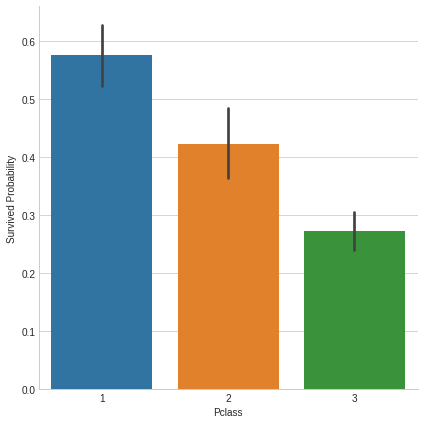

In [37]:
f = sns.factorplot(x = "Pclass",y = "Survived", data = train_df,kind = "bar", size = 6) 
f.set_ylabels("Survived Probability")
plt.show()

<a id = "16"></a><br>
## Age - Survived

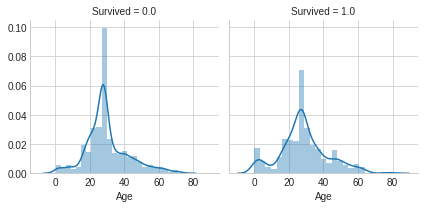

In [38]:
f = sns.FacetGrid(train_df,col = "Survived")
f.map(sns.distplot, "Age", bins = 25)
plt.show()

<a id = "17"></a><br>
## Pclass - Survived - Age

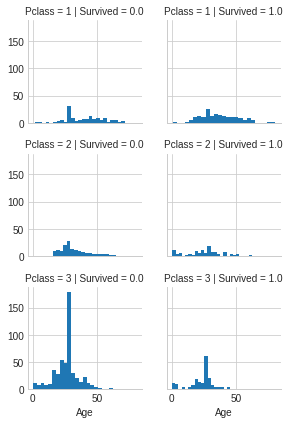

In [39]:
f = sns.FacetGrid(train_df, col = "Survived", row = "Pclass", size = 2)
f.map(plt.hist, "Age", bins = 25)
f.add_legend()
plt.show()

<a id = "18"></a><br>
## Embarked - Sex - Pclass - Survived

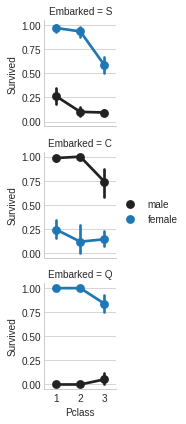

In [40]:
f = sns.FacetGrid(train_df, row = "Embarked", size = 2)
f.map(sns.pointplot, "Pclass","Survived","Sex")
f.add_legend()
plt.show()

<a id = "19"></a><br>
## Embarked - Sex - Fare - Survived

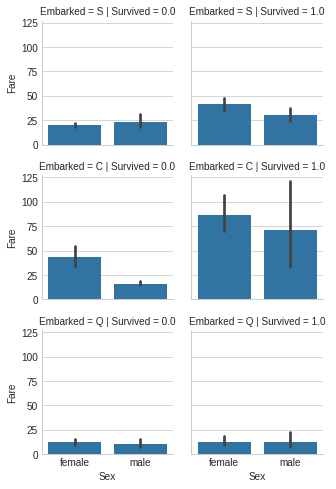

In [41]:
f = sns.FacetGrid(train_df, row="Embarked",col="Survived",size = 2.3)
f.map(sns.barplot,"Sex","Fare")
f.add_legend()
plt.show()

<a id = "20"></a><br>
## Fill Missing : Age Feature

In [42]:
train_df[train_df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked


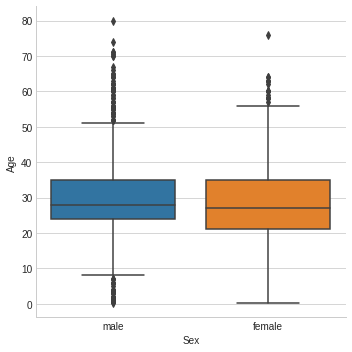

In [43]:
sns.factorplot(x = "Sex", y = "Age", data = train_df, kind="box")
plt.show()

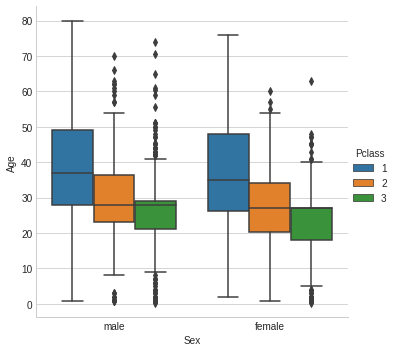

In [44]:
sns.factorplot(x = "Sex", y = "Age", hue="Pclass",data = train_df, kind="box")
plt.show()

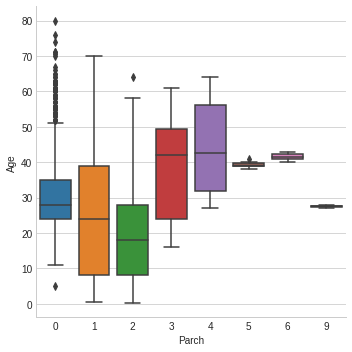

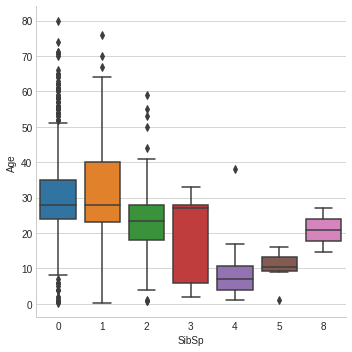

In [45]:
sns.factorplot(x = "Parch", y = "Age", data = train_df, kind = "box")
sns.factorplot(x = "SibSp", y = "Age", data = train_df, kind = "box")
plt.show()

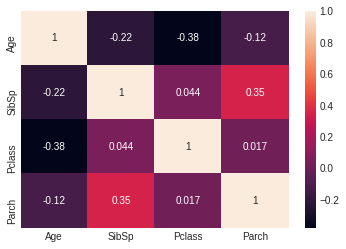

In [46]:
sns.heatmap(train_df[["Age","Sex","SibSp","Pclass","Parch"]].corr(),annot = True)
plt.show()

In [47]:
index_nanAge = list(train_df["Age"][train_df["Age"].isnull()].index)
for i in index_nanAge:
    age_pred = train_df["Age"][((train_df["SibSp"] == train_df.iloc[i]["SibSp"]) & (train_df["Parch"] == train_df.iloc[i]["Parch"]) & (train_df["Pclass"] == train_df.iloc[i]["Parch"]))].median()
    age_med = train_df["Age"].median()
    if not np.isnan(age_pred):
        train_df["Age"].iloc[i] = age_pred
    else:
        train_df["Age"].iloc[i] = age_med

<a id = "21"></a><br>
# Feature Engineering

In [48]:
train_df["NEW_TITLE"] = train_df["Name"].str.extract(" ([A-Za-z]+)\. ", expand=False)
train_df["NEW_NAME_COUNT"] = train_df["Name"].str.len()
train_df["NEW_NAME_WORD_COUNT"] = train_df.Name.apply(lambda name: len(str(name).split(" ")))
train_df["NEW_FAMILY_SIZE"] = train_df.SibSp + train_df.Parch + 1
train_df["NEW_AGE_PCLASS"] = train_df.Age * train_df.Pclass

train_df.loc[((train_df['SibSp'] + train_df['Parch']) > 0), "NEW_IS_ALONE"] = "NO"
train_df.loc[((train_df['SibSp'] + train_df['Parch']) == 0), "NEW_IS_ALONE"] = "YES"

train_df.loc[(train_df["Age"] < 15), "NEW_AGE_CAT"] = "child"
train_df.loc[(train_df["Age"] >= 15) & (train_df["Age"] < 25), "NEW_AGE_CAT"] = "young"
train_df.loc[(train_df["Age"] >= 25) & (train_df["Age"] < 35), "NEW_AGE_CAT"] = "adult"
train_df.loc[(train_df["Age"] >= 35) & (train_df["Age"] < 50), "NEW_AGE_CAT"] = "mature"
train_df.loc[(train_df["Age"] >= 50), "NEW_AGE_CAT"] = "senior"

train_df.loc[(train_df["Sex"] == "male") & (train_df["Age"] < 15), "NEW_SEX_CAT"] = "childmale"
train_df.loc[(train_df["Sex"] == "male") & (train_df["Age"] >= 15) & (train_df["Age"] < 25), "NEW_SEX_CAT"] = "youngmale"
train_df.loc[(train_df["Sex"] == "male") & (train_df["Age"] >= 25) & (train_df["Age"] < 35), "NEW_SEX_CAT"] = "adultmale"
train_df.loc[(train_df["Sex"] == "male") & (train_df["Age"] >= 35) & (train_df["Age"] < 50), "NEW_SEX_CAT"] = "maturemale"
train_df.loc[(train_df["Sex"] == "male") & (train_df["Age"] >= 50), "NEW_SEX_CAT"] = "seniormale"

train_df.loc[(train_df["Sex"] == "female") & (train_df["Age"] < 15), "NEW_SEX_CAT"] = "childfemale"
train_df.loc[(train_df["Sex"] == "female") & (train_df["Age"] >= 15) & (train_df["Age"] < 25), "NEW_SEX_CAT"] = "youngfemale"
train_df.loc[(train_df["Sex"] == "female") & (train_df["Age"] >= 25) & (train_df["Age"] < 35), "NEW_SEX_CAT"] = "adultfemale"
train_df.loc[(train_df["Sex"] == "female") & (train_df["Age"] >= 35) & (train_df["Age"] < 50), "NEW_SEX_CAT"] = "maturefemale"
train_df.loc[(train_df["Sex"] == "female") & (train_df["Age"] >= 50), "NEW_SEX_CAT"] = "seniorfemale"

In [49]:
def label_encoder(dataframe, binary_col):
    labelencoder = preprocessing.LabelEncoder()
    dataframe[binary_col] = labelencoder.fit_transform(dataframe[binary_col])
    return dataframe


def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

In [50]:
from sklearn import preprocessing

train_df.columns = [col.upper() for col in train_df.columns]


########################################################
# Label Encoding
########################################################

train_df.head()
train_df.shape

binary_cols = [col for col in train_df.columns if len(train_df[col].unique()) == 2 and train_df[col].dtypes == 'O']

for col in binary_cols:
   train_df = label_encoder(train_df, col)

train_df.columns


########################################################
# One-Hot Encoding
########################################################

ohe_cols = [col for col in train_df.columns if 10 >= len(train_df[col].unique()) > 2]

train_df = one_hot_encoder(train_df, ohe_cols, True)

train_df.head()

,PASSENGERID,SURVIVED,NAME,SEX,AGE,FARE,NEW_TITLE,NEW_NAME_COUNT,NEW_AGE_PCLASS,NEW_IS_ALONE,...,NEW_AGE_CAT_young,NEW_SEX_CAT_adultmale,NEW_SEX_CAT_childfemale,NEW_SEX_CAT_childmale,NEW_SEX_CAT_maturefemale,NEW_SEX_CAT_maturemale,NEW_SEX_CAT_seniorfemale,NEW_SEX_CAT_seniormale,NEW_SEX_CAT_youngfemale,NEW_SEX_CAT_youngmale
0,1,0.0,"Braund, Mr. Owen Harris",1,22.0,7.2500,Mr,23,66.0,0,...,1,0,0,0,0,0,0,0,0,1
1,2,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,71.2833,Mrs,51,38.0,0,...,0,0,0,0,1,0,0,0,0,0
2,3,1.0,"Heikkinen, Miss. Laina",0,26.0,7.9250,Miss,22,78.0,1,...,0,0,0,0,0,0,0,0,0,0
3,4,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,53.1000,Mrs,44,35.0,0,...,0,0,0,0,1,0,0,0,0,0
4,5,0.0,"Allen, Mr. William Henry",1,35.0,8.0500,Mr,24,105.0,1,...,0,0,0,0,0,1,0,0,0,0


<a id = "28"></a><br>
## Drop Passenger ID and Cabin

In [51]:
train_df.drop(labels = ["PASSENGERID"],axis = 1,inplace = True)

In [52]:
train_df.columns

Index(['SURVIVED', 'NAME', 'SEX', 'AGE', 'FARE', 'NEW_TITLE', 'NEW_NAME_COUNT',
       'NEW_AGE_PCLASS', 'NEW_IS_ALONE', 'PCLASS_2', 'PCLASS_3', 'SIBSP_1',
       'SIBSP_2', 'SIBSP_3', 'SIBSP_4', 'SIBSP_5', 'SIBSP_8', 'PARCH_1',
       'PARCH_2', 'PARCH_3', 'PARCH_4', 'PARCH_5', 'PARCH_6', 'PARCH_9',
       'EMBARKED_Q', 'EMBARKED_S', 'NEW_NAME_WORD_COUNT_4',
       'NEW_NAME_WORD_COUNT_5', 'NEW_NAME_WORD_COUNT_6',
       'NEW_NAME_WORD_COUNT_7', 'NEW_NAME_WORD_COUNT_8',
       'NEW_NAME_WORD_COUNT_9', 'NEW_NAME_WORD_COUNT_14', 'NEW_FAMILY_SIZE_2',
       'NEW_FAMILY_SIZE_3', 'NEW_FAMILY_SIZE_4', 'NEW_FAMILY_SIZE_5',
       'NEW_FAMILY_SIZE_6', 'NEW_FAMILY_SIZE_7', 'NEW_FAMILY_SIZE_8',
       'NEW_FAMILY_SIZE_11', 'NEW_AGE_CAT_child', 'NEW_AGE_CAT_mature',
       'NEW_AGE_CAT_senior', 'NEW_AGE_CAT_young', 'NEW_SEX_CAT_adultmale',
       'NEW_SEX_CAT_childfemale', 'NEW_SEX_CAT_childmale',
       'NEW_SEX_CAT_maturefemale', 'NEW_SEX_CAT_maturemale',
       'NEW_SEX_CAT_seniorfemale', 'NE

In [53]:
train_df.drop(['NEW_TITLE','NAME'], axis=1, inplace=True)

<a id = "29"></a><br>
# Modeling

In [54]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

<a id = "30"></a><br>
## Train - Test - Split

In [55]:
train_df_len

881

In [56]:
test = train_df[train_df_len:]
test.drop(labels = ["SURVIVED"], axis = 1 , inplace = True)

In [57]:
test.head()

,SEX,AGE,FARE,NEW_NAME_COUNT,NEW_AGE_PCLASS,NEW_IS_ALONE,PCLASS_2,PCLASS_3,SIBSP_1,SIBSP_2,...,NEW_AGE_CAT_young,NEW_SEX_CAT_adultmale,NEW_SEX_CAT_childfemale,NEW_SEX_CAT_childmale,NEW_SEX_CAT_maturefemale,NEW_SEX_CAT_maturemale,NEW_SEX_CAT_seniorfemale,NEW_SEX_CAT_seniormale,NEW_SEX_CAT_youngfemale,NEW_SEX_CAT_youngmale
881,1,34.5,7.8292,16,103.5,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
882,0,47.0,7.0000,32,141.0,0,0,1,1,0,...,0,0,0,0,1,0,0,0,0,0
883,1,62.0,9.6875,25,124.0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
884,1,27.0,8.6625,16,81.0,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
885,0,22.0,12.2875,44,66.0,0,0,1,1,0,...,1,0,0,0,0,0,0,0,1,0


In [58]:
train = train_df[:train_df_len]
X_train = train.drop(labels = "SURVIVED", axis = 1)
Y_train = train["SURVIVED"]
X_train, X_test, Y_train , Y_test = train_test_split(X_train,Y_train, test_size = 0.33, random_state = 42)
print("X_train",len(X_train))
print("X_test",len(X_test))
print("Y_train",len(Y_train))
print("Y_test",len(Y_test))
print("test",len(test))

X_train 590
X_test 291
Y_train 590
Y_test 291
test 418


<a id = "31"></a><br>
## Simple Logistic Regression

In [59]:
log_reg = LogisticRegression()
log_reg.fit(X_train,Y_train)
acc_log_train = round(log_reg.score(X_train,Y_train)*100,2)
acc_log_test = round(log_reg.score(X_test,Y_test)*100,2)
print("Training Accuracy: % {}".format(acc_log_train))
print("Testing Accuracy: % {}".format(acc_log_test))

Training Accuracy: % 83.9
Testing Accuracy: % 82.82


<a id = "32"></a><br>
# Hyperparameter Tuning - Grid Search - Cross Validation

* Decision Tree
* SVM
* Random Forest
* KNN
* Logistic Regression

In [60]:
random_state = 42
classifier = [DecisionTreeClassifier(random_state = random_state),
             SVC(random_state = random_state),
             RandomForestClassifier(random_state = random_state),
             LogisticRegression(random_state = random_state),
             KNeighborsClassifier()]

dt_param_grid = {"min_samples_split" : range(10,500,20),
                "max_depth": range(1,20,2)}

svc_param_grid = {"kernel" : ["rbf"],
                 "gamma": [0.001, 0.01, 0.1, 1],
                 "C": [1,10,50,100,200,300,1000]}

rf_param_grid = {"max_features": [1,3,10],
                "min_samples_split":[2,3,10],
                "min_samples_leaf":[1,3,10],
                "bootstrap":[False],
                "n_estimators":[100,300],
                "criterion":["gini"]}

logreg_param_grid = {"C":np.logspace(-3,3,7),
                    "penalty": ["l1","l2"]}

knn_param_grid = {"n_neighbors": np.linspace(1,19,10, dtype = int).tolist(),
                 "weights": ["uniform","distance"],
                 "metric":["euclidean","manhattan"]}
classifier_param = [dt_param_grid,
                   svc_param_grid,
                   rf_param_grid,
                   logreg_param_grid,
                   knn_param_grid]

In [61]:
cv_result = []
best_estimators = []
for i in range(len(classifier)):
    clf = GridSearchCV(classifier[i], param_grid=classifier_param[i], cv = StratifiedKFold(n_splits = 10), scoring = "accuracy", n_jobs = -1,verbose = 1)
    clf.fit(X_train,Y_train)
    cv_result.append(clf.best_score_)
    best_estimators.append(clf.best_estimator_)
    print(cv_result[i])

Fitting 10 folds for each of 250 candidates, totalling 2500 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done 2380 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 2500 out of 2500 | elapsed:   10.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.8203389830508476
Fitting 10 folds for each of 28 candidates, totalling 280 fits


[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 280 out of 280 | elapsed:    5.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.776271186440678
Fitting 10 folds for each of 54 candidates, totalling 540 fits


...

[Parallel(n_jobs=-1)]: Done 123 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 140 out of 140 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


0.81864406779661
Fitting 10 folds for each of 40 candidates, totalling 400 fits


[Parallel(n_jobs=-1)]: Done 200 tasks      | elapsed:    1.2s


0.7661016949152541


[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:    2.2s finished


Text(0.5, 1.0, 'Cross Validation Scores')

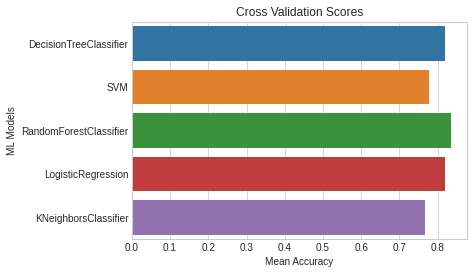

In [62]:
cv_results = pd.DataFrame({"Cross Validation Means":cv_result, "ML Models":["DecisionTreeClassifier", "SVM","RandomForestClassifier",
             "LogisticRegression",
             "KNeighborsClassifier"]})

g = sns.barplot("Cross Validation Means", "ML Models", data = cv_results)
g.set_xlabel("Mean Accuracy")
g.set_title("Cross Validation Scores")

<a id = "33"></a><br>
## Ensemble Modeling

In [63]:
votingC = VotingClassifier(estimators = [("dt",best_estimators[0]),
                                        ("rfc",best_estimators[2]),
                                        ("lr",best_estimators[3])],
                                        voting = "soft", n_jobs = -1)
votingC = votingC.fit(X_train, Y_train)
print(accuracy_score(votingC.predict(X_test),Y_test))

0.8281786941580757


<a id = "34"></a><br>
## Prediction and Submission

In [64]:
test_survived = pd.Series(votingC.predict(test), name = "Survived").astype(int)
results = pd.concat([test_PassengerId, test_survived],axis = 1)
results.to_csv("titanic.csv", index = False)